Processing: gray_0000.jpg | Shape: (360, 640) | Pixel Range: [2, 217]


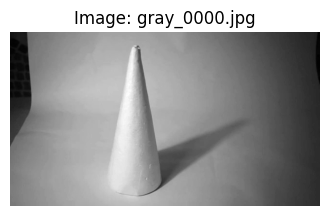

Processing: gray_0001.jpg | Shape: (360, 640) | Pixel Range: [2, 217]


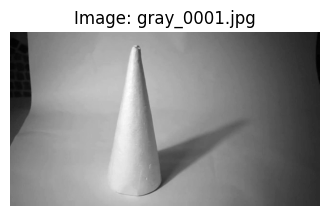

Processing: gray_0002.jpg | Shape: (360, 640) | Pixel Range: [2, 218]


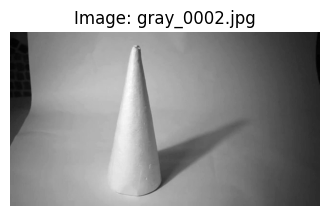

Processing: gray_0003.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0004.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0005.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0006.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0007.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0008.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0009.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0010.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0011.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0012.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0013.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0014.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0015.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_0016.jpg | Shape: (360, 640) | Pixel Range: [2, 217]
Processing: gray_001

In [1]:
import os
import cv2
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt

# Folder containing images
folder_path = "/Users/vyakhyaverma/Downloads/Geometric shapes and their light and shadow forms-2"
output_csv = "shadow_analysis_data.csv"

# Get list of image files
image_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

# Open CSV file and write data row by row
with open(output_csv, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    
    # Write header
    writer.writerow(["Filename", "Height", "Width"] + [f"Pixel_{i}" for i in range(360 * 640)])  # Assuming max size

    for idx, file_name in enumerate(image_files):
        file_path = os.path.join(folder_path, file_name)

        # Load image in grayscale
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        
        if image is not None:
            height, width = image.shape  # Get original dimensions
            print(f"Processing: {file_name} | Shape: {image.shape} | Pixel Range: [{image.min()}, {image.max()}]")

            # Preview only the first 3 images
            if idx < 3:
                plt.figure(figsize=(4, 4))
                plt.imshow(image, cmap='gray')
                plt.title(f"Image: {file_name}")
                plt.axis('off')
                plt.show()

            # Flatten and store with dimensions
            flattened_image = image.flatten().tolist()
            writer.writerow([file_name, height, width] + flattened_image)

print(f"CSV file saved: {output_csv}")

In [3]:
df = pd.read_csv("shadow_analysis_data.csv",nrows=5)
# Show as an interactive table
from IPython.display import display
display(df)

,Filename,Height,Width,Pixel_0,Pixel_1,Pixel_2,Pixel_3,Pixel_4,Pixel_5,Pixel_6,...,Pixel_230390,Pixel_230391,Pixel_230392,Pixel_230393,Pixel_230394,Pixel_230395,Pixel_230396,Pixel_230397,Pixel_230398,Pixel_230399
0,gray_0000.jpg,360,640,19,18,18,19,21,22,22,...,41,41,41,41,40,40,40,39,39,39
1,gray_0001.jpg,360,640,19,19,19,20,21,22,22,...,41,41,41,41,40,40,40,39,39,39
2,gray_0002.jpg,360,640,19,19,19,20,21,22,22,...,41,41,41,41,40,40,40,39,39,39
3,gray_0003.jpg,360,640,19,18,18,19,21,22,22,...,41,41,41,41,40,40,40,39,39,39
4,gray_0004.jpg,360,640,19,18,18,19,21,22,22,...,41,41,41,41,40,40,40,39,39,39


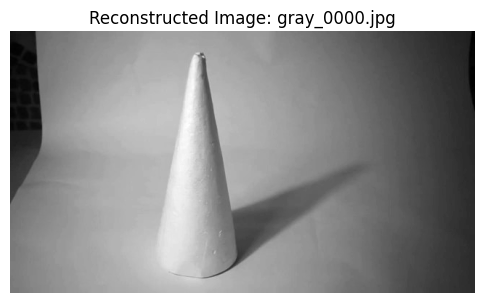

In [4]:
# Extract image data
filename = df.iloc[0, 0]  # Get filename
height = int(df.iloc[0, 1])  # Get height
width = int(df.iloc[0, 2])  # Get width
pixel_data = df.iloc[0, 3:].to_numpy(dtype=np.uint8)  # Convert pixel data to uint8

# Reshape back to original dimensions
image_reshaped = pixel_data.reshape((height, width))

# Display reconstructed image
plt.figure(figsize=(6, 6))
plt.imshow(image_reshaped, cmap='gray')
plt.title(f"Reconstructed Image: {filename}")
plt.axis("off")
plt.show()